<a href="https://colab.research.google.com/github/urashlei/mliot-pyml-2026-hw/blob/main/week01/buoi01_nguyenbaotien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bài 1 — Biểu diễn dữ liệu thành ma trận & độ tương đồng

1. Biến dữ liệu thành ma trận. Tạo ma trận X: với text là (số câu × số từ); với
ảnh là (số ảnh × H · W). In X.shape và giải thích mỗi hàng/cột đại diện cho gì.

In [1]:
import numpy as np
cau=["Bán anh em xa, mua láng giềng gần.", "Ăn cháo, đá bát.", "Có công mài sắt, có ngày nên kim.", "Anh em như thể tay chân.", "Ăn ngay nói thật, mọi tật mọi lành.", "Chớ thấy sóng cả mà rã tay chèo.", "Cá lớn nuốt cá bé.", "Con hơn cha là nhà có phúc."]
vocab=sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
  v=np.zeros(len(vocab))
  for w in s.lower().split():
    v[vocab.index(w)]+=1
  return v
X=np.array([to_vector(s) for s in cau])
print(X.shape)

(8, 46)


Sau khi vector hóa các câu, em thu được ma trận X với số hàng bằng số câu và số cột bằng số từ khác nhau trong vocab. Mỗi hàng là vector biểu diễn cho một câu, mỗi cột ứng với một từ, giá trị là số lần từ đó xuất hiện trong toàn bộ tập câu.

2. Phép toán cơ bản. Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting

In [2]:
# tính vector trung bình
tb=np.mean(X, axis=0)
print('Vector trung bình:\n', tb)
print('Shape trước:', X.shape)
# trừ trung bình (broadcasting)
Xc=X-tb
print(f'Shape sau: {Xc.shape}')

Vector trung bình:
 [0.25  0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.375
 0.125 0.125 0.25  0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.25  0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.25  0.125 0.125 0.125 0.125 0.125 0.25  0.125]
Shape trước: (8, 46)
Shape sau: (8, 46)


Mình sẽ tính vector trung bình cột để biết tần suất trung bình của từng từ. Khi trừ đi trung bình, shape của ma trận sẽ không đổi do broadcasting và các giá trị dương, âm cho thấy câu đó có từ đó nhiều hơn hay ít hơn mức chung.



3. Cosine similarity. Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [3]:
def cosine_similarity (X, Y = None ) :
  if Y is None :
    Y=X
  # chuẩn hóa theo hàng để các vector có độ dài bằng 1
  Xn=X/(np.linalg.norm (X, axis =1, keepdims=True)+ 1e-8) # thêm epsilon để tránh lỗi chia cho 0
  Yn=Y/(np.linalg.norm (Y, axis =1 ,keepdims=True)+ 1e-8)
  return Xn @ Yn.T # ma trận tương đồng

Hàm cosine_similarity làm nhiệm vụ chuẩn hóa L2 từng hàng (giữ chiều bằng keepdims=True) rồi sau đó nhân ma trận để tính độ tương đồng. Kết quả là ma trận vuông (nếu Y=None) với giá trị từ 0 đến 1 thể hiện mức độ giống nhau giữa các cặp câu.

4. Truy vấn. Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất kèm điểm cosine.

In [4]:
def search(query, top_k=3):
    # chuyển query thành vector
    q=to_vector(query).reshape(1, -1)
    # tính độ tương đồng giữa query và tất cả các câu trong X
    similar=cosine_similarity(X, q).flatten()
    # lấy index của top_k điểm cao nhất
    top=np.argsort(similar)[::-1][:top_k]
    print(f"Kết quả tìm kiếm cho: '{query}'")
    for idx in top:
        print(f"- Câu {idx}: '{cau[idx]}' (Cosine: {similar[idx]:.4f})")

search("Ăn cháo, đá bát.")
search("Anh em như thể tay chân.")

Kết quả tìm kiếm cho: 'Ăn cháo, đá bát.'
- Câu 1: 'Ăn cháo, đá bát.' (Cosine: 1.0000)
- Câu 4: 'Ăn ngay nói thật, mọi tật mọi lành.' (Cosine: 0.1581)
- Câu 6: 'Cá lớn nuốt cá bé.' (Cosine: 0.0000)
Kết quả tìm kiếm cho: 'Anh em như thể tay chân.'
- Câu 3: 'Anh em như thể tay chân.' (Cosine: 1.0000)
- Câu 0: 'Bán anh em xa, mua láng giềng gần.' (Cosine: 0.2887)
- Câu 5: 'Chớ thấy sóng cả mà rã tay chèo.' (Cosine: 0.1443)


Hàm search chuyển query thành vector, tính độ tương đồng với toàn bộ các câu, sắp xếp giảm dần và lấy top_k câu gần nhất.



5. Nhận xét. Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp trực giác không?

- Cặp giống nhau nhất (ko tính chính nó): Cặp câu Câu 3 "Anh em như thể tay chân" và Câu 0 "Bán anh em xa, mua láng giềng gần" có độ tương đồng cao nhất với chỉ số Cosine là 0.2887 vì trong không gian đặc trưng, hai câu này chia sẻ chung từ khóa là "anh" và "em"
- Cặp khác biệt nhất: Các cặp có Cosine bằng 0.0000, giống như câu "Ăn cháo, đá bát" và câu "Cá lớn nuốt cá bé", điều này có nghĩa hai vector biểu diễn chúng hoàn toàn vuông góc với nhau. Hai câu trên không có bất kỳ từ khóa chung nào trong vocab nên tích vô hướng bằng 0.
- Kết quả có khớp trực giác không?: Theo em, kết quả này khá khớp trực giác. Cặp có điểm cao thường là hai câu cùng nói về một chủ đề (ví dụ "anh em") vì chúng có nhiều từ chung. Ngược lại, cặp có điểm thấp thường là hai câu có nội dung hoàn toàn khác nhau, ít từ chung.


Bài 2 — Biến đổi tuyến tính & SVD (Lựa chọn B — Text)

1. Dùng ma trận X (câu × từ) từ Bài 1.

2. Giảm chiều bằng SVD. Dùng np.linalg.svd đưa mỗi câu về 2 chiều (LSA thu nhỏ).

In [5]:
# center dữ liệu (trừ trung bình cột)
Xc=X-X.mean(axis=0)
# phân rã SVD
U, S, Vt=np.linalg.svd(Xc, full_matrices=False)
# tạo tọa độ 2 chiều cho mỗi câu
coords=U[:, :2] * S[:2]
print("Tọa độ 2D của các câu:")
print(coords)

Tọa độ 2D của các câu:
[[-0.6393428   1.40529643]
 [-0.3271217  -0.30756735]
 [ 2.45935412 -0.61018106]
 [-0.51449209  1.07194754]
 [-1.50497757 -2.34821774]
 [-0.44638598  0.84239383]
 [-0.1843063   0.18325836]
 [ 1.15727232 -0.23693001]]


Mình center dữ liệu bằng cách trừ trung bình cột để các trục chính của SVD tập trung vào sự khác biệt giữa các câu thay vì bị ảnh hưởng bởi tần suất xuất hiện trung bình. Sau đó dùng np.linalg.svd để phân rã, lấy 2 thành phần đầu và nhân với S để có tọa độ 2D cho từng câu. Shape của coords là (8,2), mỗi hàng là một câu, mỗi cột là tọa độ trên trục chính.

3. Trực quan hóa. Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu.

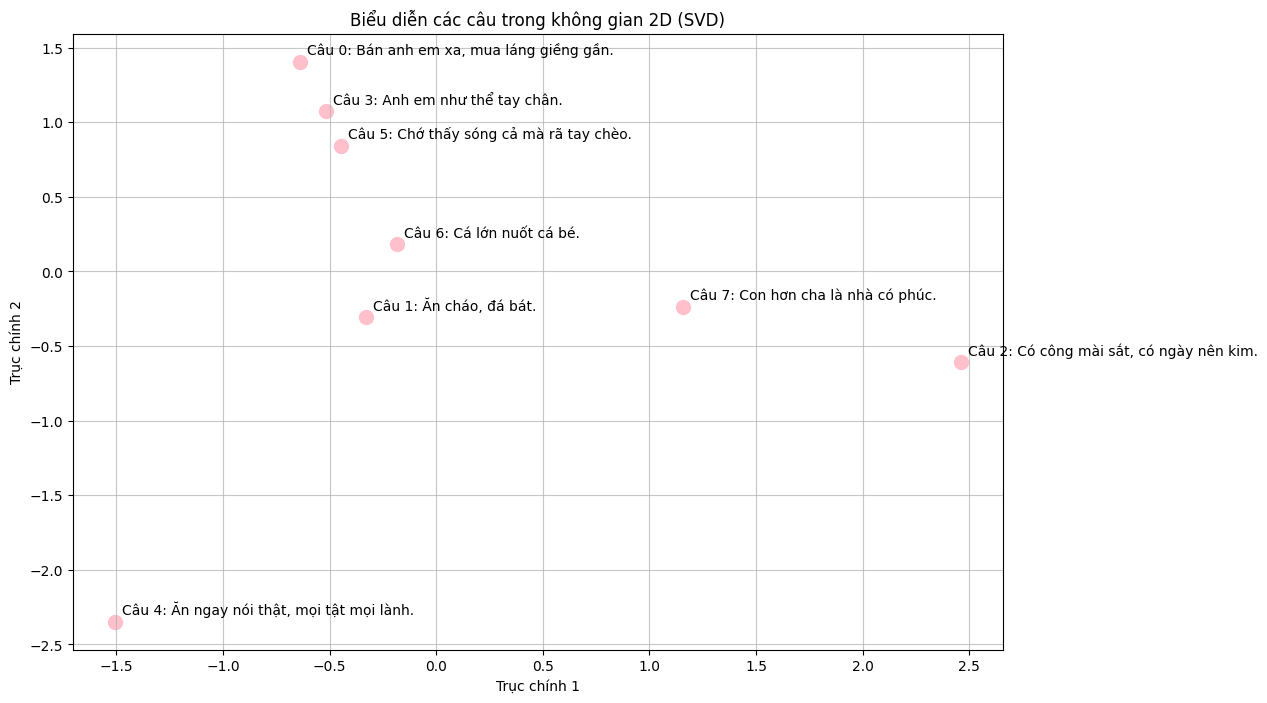

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
# vẽ scatter
plt.scatter(coords[:, 0], coords[:, 1], s=100, color='pink')
# gán nhãn cho từng câu
for i, txt in enumerate(cau):
    plt.annotate(f"Câu {i}: {txt}", (coords[i, 0], coords[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xlabel('Trục chính 1')
plt.ylabel('Trục chính 2')
plt.title('Biểu diễn các câu trong không gian 2D (SVD)')
plt.grid(True, alpha=0.7)
plt.show()

Mình vẽ scatter plot với tọa độ 2D vừa tính, mỗi điểm là một câu và gán nhãn để dễ đối chiếu. Việc trực quan hóa sẽ giúp mình hình dung rõ hơn mối quan hệ giữa các câu dựa trên từ vựng.

4. Nhận xét. Các câu cùng chủ đề có nằm gần nhau không? Liên hệ với eigen/PCA và “trục chính” của dữ liệu.

Sau khi giảm chiều bằng SVD và vẽ các câu lên mặt phẳng 2D, mình thấy:
- Các câu về tình cảm anh em (câu 0 và câu 3) nằm gần nhau ở phía trên vì có từ "anh em" chung.
- Câu 1 "Ăn cháo đá bát" và câu 4 "Ăn ngay nói thật..." đều có từ "ăn" và cùng nói về đạo đức nhưng trên đồ thị lại không gần nhau. Mình nghĩ là do ngoài từ "ăn", hai câu không có từ chung nào khác vì thế vector biểu diễn của chúng gần như trực giao, nên khi chiếu xuống 2D bị tách xa.
- Các câu cùng chủ đề có xu hướng gần nhau nhưng không phải lúc nào cũng đúng tuyệt đối. SVD chỉ dựa trên thống kê từ, không hiểu ngữ nghĩa sâu và là vì dữ liệu nhỏ nén xuống 2 chiều khiến một số cặp không được phân tách tốt.
Liên hệ với PCA/eigen và "trục chính":
- Trong PCA, các eigenvector của ma trận hiệp phương sai chỉ ra các hướng mà dữ liệu biến thiên mạnh nhất. Vector tương ứng với eigenvalue lớn nhất được gọi là trục chính (PC1), chứa đựng nhiều thông tin nhất của tập dữ liệu.
- Trục ngang (PC1): Đại diện cho chủ đề hoặc tập hợp từ khóa có sự biến thiên lớn nhất trong 8 câu.
- Trục dọc (PC2): Đại diện cho hướng biến thiên quan trọng thứ hai.
- Khi các câu nằm xa gốc tọa độ theo một trục nào đó nghĩa là câu đó đóng góp rất mạnh vào thành phần thông tin của trục đó.
==> Việc giảm chiều bằng SVD giúp mình nhìn thấy các trục chính, nơi tập trung những đặc trưng tiêu biểu nhất của tập dữ liệu.

